In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score, classification_report
from plot_decision_boundaries import plot_decision_boundaries
from plot_gaussian_mixture import plot_gaussian_mixture
from plot_dbscan import plot_dbscan


In [2]:
train = pd.read_csv("samsung_train.txt",sep=r"\s+",header=None)
train_labels = pd.read_csv("samsung_train_labels.txt",sep=r"\s+",header=None)

In [3]:
print("data")
print(train.describe())
print(train.shape)
print("labels")
print(train_labels.describe())
print(train_labels.shape)

data
               0            1            2            3            4    \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000000   
mean      0.274488    -0.017695    -0.109141    -0.605438    -0.510938   
std       0.070261     0.040811     0.056635     0.448734     0.502645   
min      -1.000000    -1.000000    -1.000000    -1.000000    -0.999873   
25%       0.262975    -0.024863    -0.120993    -0.992754    -0.978129   
50%       0.277193    -0.017219    -0.108676    -0.946196    -0.851897   
75%       0.288461    -0.010783    -0.097794    -0.242813    -0.034231   
max       1.000000     1.000000     1.000000     1.000000     0.916238   

               5            6            7            8            9    ...  \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000000  ...   
mean     -0.604754    -0.630512    -0.526907    -0.606150    -0.468604  ...   
std       0.418687     0.424073     0.485942     0.414122     0.544547  ...   
min      -1.

Dane są jakimiś cechami dotyczącymi aktywności. Jedna kolumna jedna osoba 561 cech można znaleźć jakie w Human Activity Recognition - nie wiele mówi dokładnie zapoznawanie się z tymi cechami.
Mamy już zbiór podzielony na wartości testowe i treningowe. Można by je połączyć i ponownie zrobić split, ale skoro są podane w takiej formie to tak bym je pozostawił bo takie jest zapewne założenie i taki gotowy podział lepiej obroni model przed potencjalnymi błędami. Więc mamy już teoretycznie przygotowany X_train X_test y_train i y_test.
Wydaje mi się że nie potrzebujemy na tym etapie znać tych cech czym dokłądnie są bo możemy najpierw skorzystać z klasteringu i zobaczyć jakie grupy nam wyjdą dopiero wtedy próbować je określić?.
Dane są wyskalowane w zakresie od -1,1 więc skalowanie też już jest wykonane, przynajmniej tak wynika ze strony Human Activity Recognition Using Smartphones

In [4]:
X_train = pd.read_csv("samsung_train.txt",sep=r"\s+",header=None)
y_train = pd.read_csv("samsung_train_labels.txt",sep=r"\s+",header=None)
y_train = y_train.iloc[:, 0]
X_test = pd.read_csv("samsung_test.txt",sep=r"\s+",header=None)
y_test = pd.read_csv("samsung_test_labels.txt",sep=r"\s+",header=None)
y_test = y_test.iloc[:, 0]



In [5]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

print("Braki X_train:", X_train.isna().sum().sum())
print("Braki X_test:", X_test.isna().sum().sum())
print("Duplikaty w X_train:", X_train.duplicated().sum())

(7352, 561)
(7352,)
(2947, 561)
(2947,)
Braki X_train: 0
Braki X_test: 0
Duplikaty w X_train: 0


Dane wyglądają na kompletne i przygotowane do analizy, nie widze błędów zerowych wartości duplikatów. Okazuje się że w danych jest rodzaj aktywności których jest sześć więc tyle należy obrać n_clusters dla KMeans

In [6]:
models = {
    'KMeans': KMeans(
        n_clusters= 6,
        random_state = 1,
        n_init= 10
    ),
    'MiniBatchKMeans': MiniBatchKMeans(
        n_clusters= 6,
        random_state = 1,
        n_init= 10
    ),
    'dbscan' : DBSCAN(
        eps=1,
        min_samples = 5
    ),
    'GaussianMixture' : GaussianMixture(
        n_components= 6,
        random_state= 1
    )
}

supervised_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=  1000,
        random_state= 1
    ),
    'DecissionTreeClassifier': DecisionTreeClassifier(
        random_state= 1
    )
}

Spróbuje sprawdzić jak klasteryzacja poradziła sobie z podzieleniem zbiorów na 6 klastrów ponieważ my tak naprawdę znamy podział który chcielibyśmy uzyskać.

In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
clustering_results = {}

for name, model in models.items():
    y_pred = model.fit_predict(X_train)

    ari = adjusted_rand_score(y_train, y_pred)
    nmi = normalized_mutual_info_score(y_train, y_pred)

    clustering_results[name] = {
        "model": model,
        "predictions": y_pred,
        "ARI": ari,
        "NMI": nmi
    }

    print(f"{name}")
    print(f"ARI: {ari:.3f}")
    print(f"NMI: {nmi:.3f}")
    print()



KMeans
ARI: 0.455
NMI: 0.583

MiniBatchKMeans
ARI: 0.462
NMI: 0.591

dbscan
ARI: 0.000
NMI: 0.000

GaussianMixture
ARI: 0.286
NMI: 0.464



In [8]:
pca_2d = PCA(n_components=2, random_state=1)
X_train_2d = pca_2d.fit_transform(X_train)

In [9]:
for eps in [0.34, 0.35, 0.36]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_train_2d)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps}: klastry={n_clusters}, "
        f"szum={n_noise} ({n_noise / len(labels):.1%})"
    )

eps=0.34: klastry=7, szum=108 (1.5%)
eps=0.35: klastry=6, szum=104 (1.4%)
eps=0.36: klastry=5, szum=94 (1.3%)


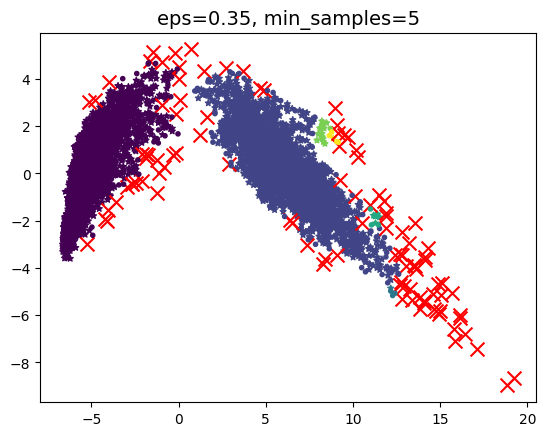

In [10]:
dbscan = DBSCAN(eps=0.35, min_samples=5)
dbscan.fit(X_train_2d)
plot_dbscan(dbscan,X_train_2d,size=5)

DBSCAN dobrałem tak żeby było 6 klastrów ale są dwa duże zbiory możliwe że przesłanaiją za pomocą metody plot DBSCAN i dlatego nie widać lepiej?

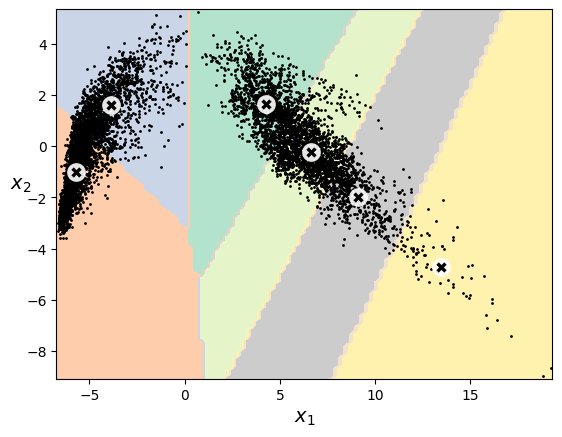

In [11]:
MiniBatchKMeans_clf = MiniBatchKMeans(n_clusters=6, max_iter=100000, random_state=1)
MiniBatchKMeans_clf.fit(X_train_2d)

plot_decision_boundaries(MiniBatchKMeans_clf, X_train_2d)

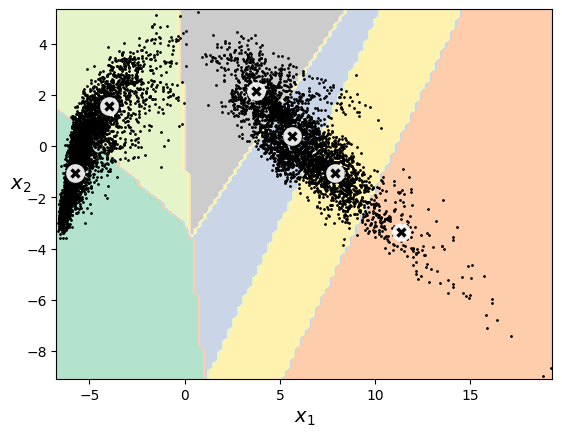

In [12]:
KMeans_clf = KMeans(n_clusters=6, max_iter=100000, random_state=1)
KMeans_clf.fit(X_train_2d)

plot_decision_boundaries(KMeans_clf, X_train_2d)

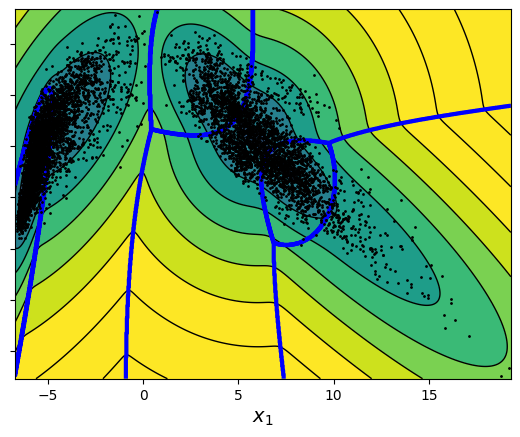

In [13]:
GaussianMixture_clf = GaussianMixture(n_components= 6, random_state=1)
GaussianMixture_clf.fit(X_train_2d)

plot_gaussian_mixture(GaussianMixture_clf, X_train_2d)

In [14]:
from sklearn.metrics import accuracy_score, f1_score
preprocessor = Pipeline([
    # ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=0.95,
        random_state=1
    ))
])
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clustering", KMeans(
        n_clusters=6,
        random_state=42,
        n_init= 10
        
    )),
    ("classifier", LogisticRegression(
        max_iter=20000,
        random_state=1
    ))
])
pipeline_name = "KMeans + Logistic Regression"
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))


KMeans + Logistic Regression
Accuracy: 0.7611129962673906
F1 macro: 0.753378654619273


In [15]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=1
        
    ))
])
pipeline_name = "Logistic Regression + Preprocessor"
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:",f1_score(y_test, y_pred, average="macro"))

Logistic Regression + Preprocessor
Accuracy: 0.9416355615880556
F1 macro: 0.940586853654092


In [16]:
model_pipeline = Pipeline([
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=1
    ))
])
pipeline_name = "Logistic Regression"
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:",f1_score(y_test, y_pred, average="macro"))

Logistic Regression
Accuracy: 0.9619952494061758
F1 macro: 0.9620578909975772


Połączenie danych przed klasyfikatorem

In [20]:
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import GridSearchCV

features = FeatureUnion([
    ("original_features", FunctionTransformer()),
    ("clustering", KMeans(
        n_clusters=6,
        random_state=1,
    ))
])
model_pipeline = Pipeline([
    ("features", features),

    # ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=1
    ))
])

params = {
    "classifier__C": np.logspace(-5, 5, 40)
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

pipeline_name = "Oryginalne cechy + KMeans + Logistic Regression + Grid Search"

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = grid_search.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(
    "F1 macro:",
    f1_score(y_test, y_pred, average="macro")
)


activity_labels = [1, 2, 3, 4, 5, 6]

activity_names = [
    "marsz",
    "wchodzenie po schodach",
    "schodzenie ze schodów",
    "siedzenie",
    "stanie",
    "leżenie"
]
report = classification_report(
    y_test,
    y_pred,
    labels=activity_labels,
    target_names=activity_names,
    output_dict=True,
    zero_division=0
)

activity_results = (
    pd.DataFrame(report)
    .T
    .loc[activity_names, ["precision", "recall", "f1-score"]]
)

print(activity_results)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Oryginalne cechy + KMeans + Logistic Regression + Grid Search
Accuracy: 0.9623345775364778
F1 macro: 0.9623797571764815
                        precision    recall  f1-score
marsz                    0.944444  0.993952  0.968566
wchodzenie po schodach   0.975930  0.946921  0.961207
schodzenie ze schodów    0.992701  0.971429  0.981949
siedzenie                0.975113  0.877800  0.923901
stanie                   0.902946  0.979323  0.939585
leżenie                  0.998141  1.000000  0.999070


In [21]:

model_pipeline = Pipeline([
    ("features", features),

    # ("scaler", StandardScaler()),

    ("classifier", DecisionTreeClassifier(
        random_state=1
    ))
])

params = {
    "classifier__criterion": ["gini", "entropy"],

    "classifier__max_depth": [
        None, 5, 10, 20
    ],

    "classifier__min_samples_split": [
        2, 5, 10
    ],

    "classifier__min_samples_leaf": [
        1, 2, 5
    ]
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

pipeline_name = "Oryginalne cechy + KMeans + DecissionTree + Grid Search"

grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(
    "F1 macro:",
    f1_score(y_test, y_pred, average="macro")
)

activity_names = [
    "marsz",
    "wchodzenie po schodach",
    "schodzenie ze schodów",
    "siedzenie",
    "stanie",
    "leżenie"
]

print(classification_report(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5, 6],
    target_names=activity_names,
    digits=3
))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Oryginalne cechy + KMeans + DecissionTree + Grid Search
Accuracy: 0.8561248727519511
F1 macro: 0.8536091299138651
                        precision    recall  f1-score   support

                 marsz      0.819     0.913     0.864       496
wchodzenie po schodach      0.856     0.758     0.804       471
 schodzenie ze schodów      0.861     0.855     0.858       420
             siedzenie      0.799     0.776     0.787       491
                stanie      0.799     0.820     0.809       532
               leżenie      1.000     1.000     1.000       537

              accuracy                          0.856      2947
             macro avg      0.856     0.854     0.854      2947
          weighted avg      0.857     0.856     0.856      2947



Kolejene wykorzystania scalera w momencie kiedy dane są już włąsciwie przeskalowane obniża.

Najlepszy wynik przy - Oryginalne cechy + KMeans + Logistic Regression + Grid Search
Accuracy: 0.9623345775364778
F1 macro: 0.9623797571764815

Modele najlepiej radziły sobie z aktywnościami nie wymagającymi wysiłku lepiej siedzienie od stania, lepiej schodzenie ze schodów niż wchodznie a najlepiej ze spaniem.

Czym różni się KMeans, K-fold i K Nearest Neighbors - właściwie powinno się zapytać co je łączy, bo to są zupełnie odmienne 'metody' KMeans - metoda nauki unsupervised gdzie K oznacza podziel na K-liczbę klastrów. K-Nearest Neighbors to klasyfikator sposobu nauki supervised który sprawdza najbliżysz sąsiadów zbioru i tworzy predykcje w oparciu o K-liczę sąsiadów. Łączy je wrażliwość na odległości między obserwacjami. KFold jest natomiast sposobem podziału danych, dzieli dane na foldy np K liczba foldów gdzie model uczy się K-1 porcji danych a jedna część służy do walidacji.
